Processing traces: 100%|██████████| 1/1 [00:00<00:00, 197.44batch/s]


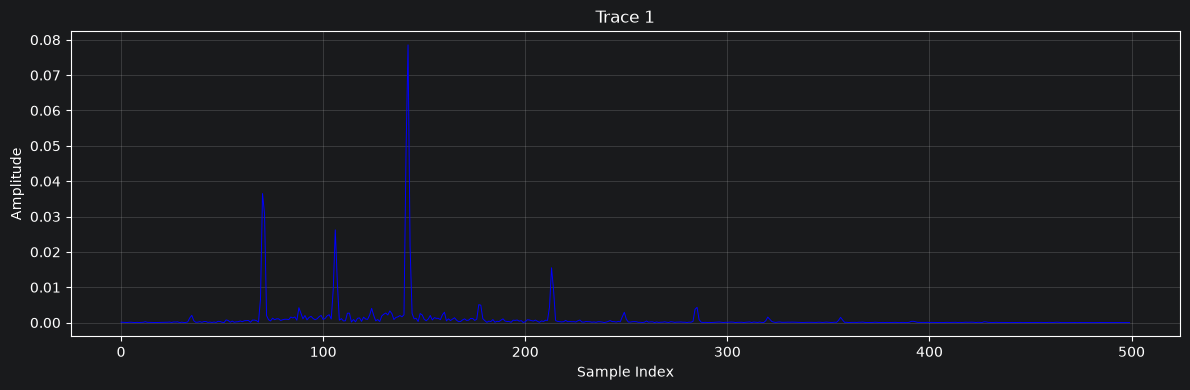

In [1]:
from scapyter.domain.signal_processing.fft.fft_processor import FFTProcessor
from scapyter.ui.trace_plotter import TracePlotter
from scapyter.infrastructure.h5_project_file_reader import H5ProjectFileReader
from scapyter.domain.value_object import RangeParameters, Range
from scapyter.domain.signal_processing.fft.window_type import WindowFunctionType

from scapyter.application.trace_processing_service import TraceProcessingService

output_file = "ft_output.h5"

service = TraceProcessingService(
    input_path="../../data/smart-card-project/smart_card_project.sx",
    output_path=output_file,
    processor=FFTProcessor(
        window_type=WindowFunctionType.HAMMING,
    ),
    range_parameters=RangeParameters(
        trace_range=Range(0, 100), sample_range=Range(0, 1000)
    ),
)

service.run()

trace_repo = H5ProjectFileReader(output_file)
trace_plotter = TracePlotter(trace_repo)
trace_plotter.plot_single(index=1)